## 1. Perceptron learning algorithm
[10 = dataset creation 2 + perceptron learning algorithm 5 + analysis 3]
* Implement perceptron learning algorithm for classifying a linearly separable dataset in 2D. Note
that you have to create such a dataset with at least 1000 data points. Plot the dataset before and
after training (with the classifier).
* Discuss your observations with respect to number of iterations required for perfect classification (k)
by varying the level of separability (γ from the class discussions) in the dataset. (Hint: compute
the average value of k for each level of γ, and do this for about 5 values of γ. Observe if you can
relate to the result discussed in class)

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from graphviz import Digraph
#from micrograd.engine import Value
%matplotlib inline

### 1(a). Data Generation

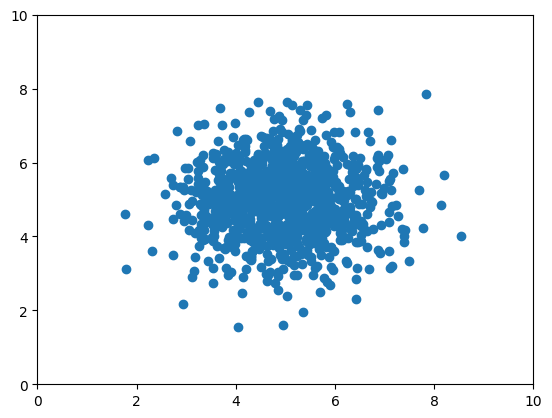

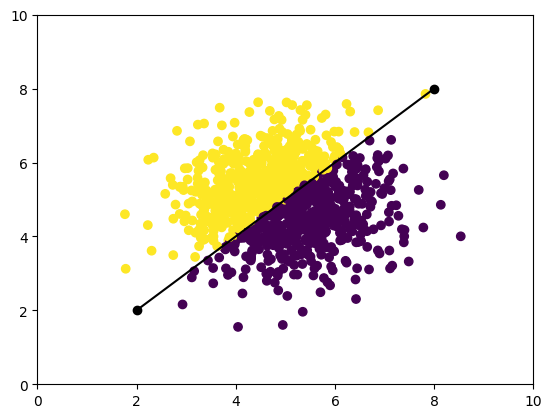

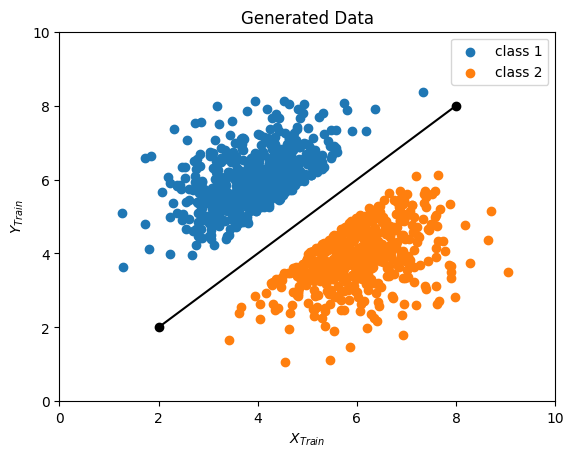

In [2]:
np.random.seed(1024)

# End points of the line
#a = np.array([-.1,-.1])
#b = np.array([.1,.1])

a = np.array([2.0,2.0])
b = np.array([8.0,8.0])

# Generating 1000 data points
mu = [5.,5.]
cov= np.diag([1.0,1.0])
x1, y1 = np.random.multivariate_normal(mu, cov, 1000).T
data = np.column_stack((x1,y1))
plt.scatter(data[:,0],data[:,1])
plt.xlim(0,10)
plt.ylim(0,10)
plt.show()
#Data seperation
isabove = lambda p, a,b: np.cross(p-a, b-a) < 0
#Plotting a line
plt.plot([a[0],b[0]],[a[1],b[1]], marker="o", color="k")
plt.scatter(data[:,0],data[:,1], c=isabove(data,a,b),vmin=0, vmax=1)
plt.xlim(0,10)
plt.ylim(0,10)
plt.show()

#Parameter for seperation
gamma = 0.5

#Indexes of class above and below line.
c1 = np.argwhere(np.cross(data-a, b-a)< 0)
c2 = np.argwhere(np.cross(data-a, b-a)> 0)
data[c1,0] -=gamma
data[c1,1] +=gamma
data[c2,0] +=gamma
data[c2,1] -=gamma

#Ploting data
plt.plot([a[0],b[0]],[a[1],b[1]], marker="o", color="k")
plt.scatter(data[c1,0],data[c1,1],label='class 1')
plt.scatter(data[c2,0],data[c2,1],label='class 2')
plt.legend()
plt.xlim(0,10)
plt.ylim(0,10)
plt.xlabel(r'$X_{Train}$')
plt.ylabel(r'$Y_{Train}$')
plt.title("Generated Data")
plt.show()

### 1(b). Perceptron Learning Algorithm

In [3]:
class Perceptron:
    def __init__(self, N, alpha=0.1):
        self.W = np.random.randn(N+1)/np.sqrt(N)
        self.alpha = alpha

    def step(self, x):

        #return 1 if 1/(1+np.exp(-x)) > 0 else 0
        return 1 if x>0 else 0

    def fit(self, X, y, epochs=10):
        # X is training data, y is target output
        X = np.c_[X, np.ones((X.shape[0]))]
        #Iterate for no. of epochs
        for epoch in np.arange(0,epochs):
            #Loop over each data
            for (x,target) in zip(X,y):
                #Take the dott product
                p = self.step(np.dot(x, self.W))
                if p != target:
                    error = p-target
                    self.W += -self.alpha * error*x

    def predict(self, X, addBias=True):
        X = np.atleast_2d(X)
        if addBias:
            X = np.c_[X, np.ones((X.shape[0]))]
        return self.step(np.dot(X, self.W))


### Sample Dataset

In [4]:
# Sample dataset
X = np.array([[0, 0, 0], [0, 0, 1], [0, 1, 0], [0, 1, 1], [1, 0, 0], [1, 0, 1], [1, 1, 0], [1, 1, 1]])
y = np.array([[0], [0], [0], [1], [0], [1], [1], [1]])
# define our perceptron and train it
print("Training perceptron...")
p = Perceptron(X.shape[1], alpha=0.1)
p.fit(X, y, epochs=20)

print("[Testing perceptron...")
# Loop over the dataset
for (x, target) in zip(X, y):
	#Predict data
	pred = p.predict(x)
	print("data={}, ground-truth={}, pred={}".format(x, target[0], pred))

Training perceptron...
[Testing perceptron...
data=[0 0 0], ground-truth=0, pred=0
data=[0 0 1], ground-truth=0, pred=0
data=[0 1 0], ground-truth=0, pred=0
data=[0 1 1], ground-truth=1, pred=1
data=[1 0 0], ground-truth=0, pred=0
data=[1 0 1], ground-truth=1, pred=1
data=[1 1 0], ground-truth=1, pred=1
data=[1 1 1], ground-truth=1, pred=1


In [5]:
data_c1 = np.c_[data[c1[:,0]], np.zeros(c1.shape[0])]
data_c2 = np.c_[data[c2[:,0]], np.ones(c2.shape[0])]

X_train = np.concatenate([data_c1,data_c2])
X = X_train[:,:2]
y = X_train[:,2]
# define our perceptron and train it
print("Training perceptron...")
p = Perceptron(X.shape[1], alpha=0.1)
p.fit(X, y, epochs=20)

Training perceptron...


In [6]:
# now that our perceptron is trained we can evaluate it
print("Testing perceptron...\n")
# now that our network is trained, loop over the data points

print("Class 0")
for (x, target) in zip(X[:5], y[:5]):
	# make a prediction on the data point and display the result
	# to our console
	pred = p.predict(x)
	print('data={}, ground-truth={}, pred={}'.format(x, target, pred))
print("Class 1")
for (x, target) in zip(X[-5:], y[-5:]):
	# make a prediction on the data point and display the result
	# to our console
	pred = p.predict(x)
	print('data={}, ground-truth={}, pred={}'.format(x, target, pred))

Testing perceptron...

Class 0
data=[2.62470096 4.93149307], ground-truth=0.0, pred=0
data=[4.43489859 6.30681666], ground-truth=0.0, pred=0
data=[3.9221824  6.07306064], ground-truth=0.0, pred=0
data=[4.16332504 5.79700734], ground-truth=0.0, pred=0
data=[4.12519584 5.65510474], ground-truth=0.0, pred=0
Class 1
data=[6.17355471 3.76193842], ground-truth=1.0, pred=1
data=[7.98754735 2.82232438], ground-truth=1.0, pred=1
data=[5.9663697  2.99590844], ground-truth=1.0, pred=1
data=[6.30991201 4.16416863], ground-truth=1.0, pred=1
data=[6.79992123 4.30953037], ground-truth=1.0, pred=1


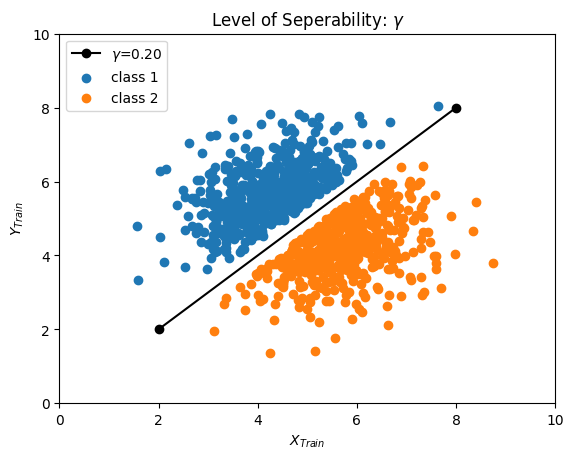

In [7]:
np.random.seed(1024)
mean = [5.,5.]
cov= np.diag([1.0,1.0])
xd, yd = np.random.multivariate_normal(mean, cov, 1000).T
pdata = np.column_stack((xd,yd))
gamma = 0.2
def seperability(pdata,a,b,gamma=0.5):

    #Indexes of class above and below line.
    c1 = np.argwhere(np.cross(data-a, b-a)< 0)
    c2 = np.argwhere(np.cross(data-a, b-a)> 0)
    pdata[c1,0] -= gamma
    pdata[c1,1] += gamma
    pdata[c2,0] += gamma
    pdata[c2,1] -= gamma

    #Ploting data
    plt.plot([a[0],b[0]],[a[1],b[1]], marker="o", color="k", label=r"$\gamma$=%.2f"%gamma)
    plt.scatter(pdata[c1,0],pdata[c1,1],label='class 1')
    plt.scatter(pdata[c2,0],pdata[c2,1],label='class 2')
    plt.xlim(0,10)
    plt.ylim(0,10)
    plt.legend()
    plt.xlabel(r'$X_{Train}$')
    plt.ylabel(r'$Y_{Train}$')
    plt.title(r"Level of Seperability: $\gamma$ ")
    plt.show()

seperability(pdata, a,b,gamma)

### 2. Gradient descent for training a linear classifier
[10 = loss formulation 4 + gradient computation 3 + update equation 3]
* Consider solving the above problem (training a line for classifying a linearly separable 2D dataset) using Gradient Descent algorithm. Think of a loss function (beyond simple MSE) based on our classroom discussion on the desirable properties of a loss function. You may implement the analytical way of finding gradient for it. You may implement the basic version of gradient descent update equation. Plot the dataset before and after training (with the classifier).
    

### 3. MLP with a single hidden layer
[20 = dataset creation 5 + MLP definition 5 + backprop 10]
This question has two variations, and you are expected to attempt any one of the variations. The
second variation, if implemented properly, will fetch you a 5% bonus on this assignment.
* Original Question: Consider a binary classification dataset that is not linearly separable in 2D
(e.g. data lying on the circumference two concentric circles). Train a Multi layer perceptron (MLP)
with a single hidden layer for classifying the same. You may use the loss function used in problem
* You have to implement the backpropagation algorithm yourself.
* $Variation:$ Implement your own toy autograd engine, and use it to solve the original question. You are welcome to discuss the approach with TAs if you like.

### 3(a). Dataset Creation

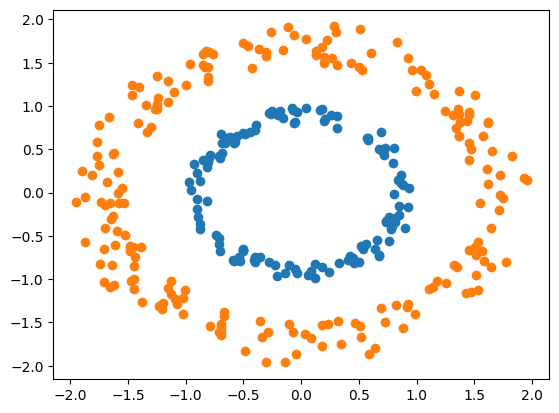

In [8]:
# Generating 1000 data points
np.random.seed(1024)
mu = [0.,0.]
cv= np.diag([1.0,1.0])
DP = 1000
cx1, cy1 = np.random.multivariate_normal(mu, cv, DP).T
rdata = np.column_stack((cx1,cy1))
c1x = []; c1y = []; c2x = []; c2y = []

for i in range(DP):
    if 0.8<np.sqrt(cx1[i]**2 + cy1[i]**2)<=1.0:
        c1x.append(cx1[i])
        c1y.append(cy1[i])
    if 1.5<np.sqrt(cx1[i]**2 + cy1[i]**2)<=2.0:
        c2x.append(cx1[i])
        c2y.append(cy1[i])

c1_data = np.column_stack((c1x,c1y))
c2_data = np.column_stack((c2x,c2y))

plt.scatter(c1_data[:,0],c1_data[:,1])
plt.scatter(c2_data[:,0],c2_data[:,1])
plt.show()

### Implementing Variation

### Toy implementation of micrograd in another notebook